In [1]:
# !pip install xgboost lightgbm catboost


# Movie Revenue Modeling With Faster Hyperparameter Search

This version of the notebook is designed for long-running server jobs.

It improves tuning speed by:
- avoiding nested parallelism
- using `RandomizedSearchCV` for expensive models instead of full cartesian grids
- keeping `GridSearchCV` only for small cheap searches
- defaulting to a faster screening run so you can identify strong models first
- saving checkpoints and best estimators as the search runs


## Dataset Summary

,Metric,Value
0,Rows,"16,440"
1,Columns in source dataset,22
2,Model features used,"budget, runtime, actor_1_popularity, actor_2_popularity, actor_3_popularity, original_language, mpaa_rating"
3,Total missing values in X,0
4,Revenue skewness,9.62


## Search Configuration

,Setting,Value
0,Available CPU cores,16
1,Search workers used,16
2,Estimator internal workers,1
3,Cross-validation folds,3
4,Fast mode,True
5,Checkpoint file,Dataset\comparison_outputs\modeling_outputs\fast_search\movie_model_results_checkpoint.csv
6,Best-model directory,Dataset\comparison_outputs\modeling_outputs\fast_search\best_model_checkpoints


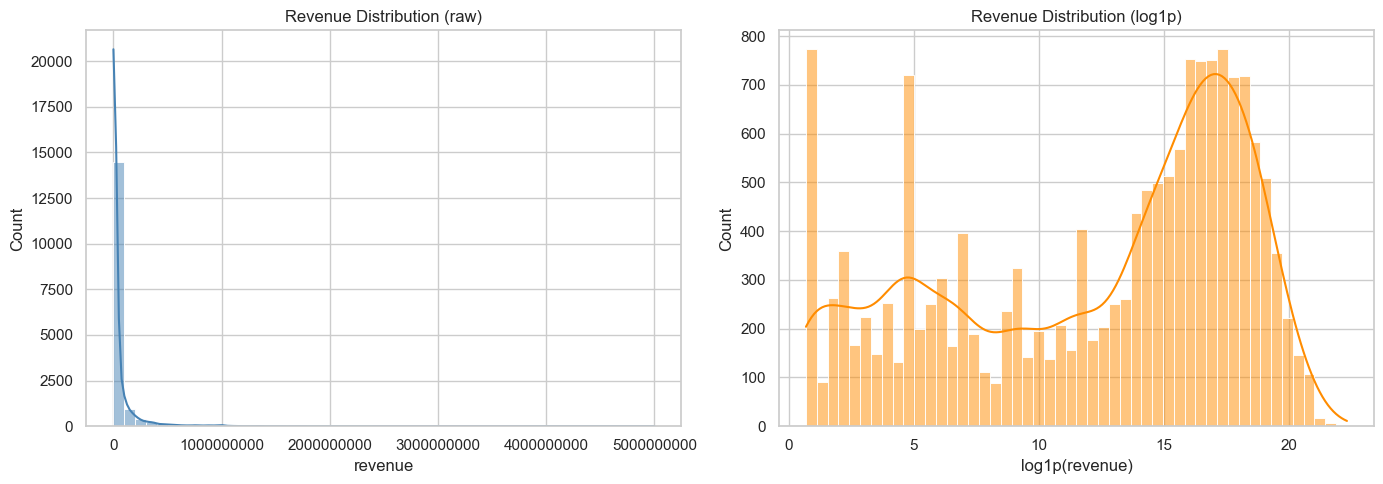

In [ ]:
import os

# Keep math libraries single-threaded so GridSearchCV / RandomizedSearchCV can own the parallelism.
# Restart the kernel after editing these values.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from joblib import dump

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, ParameterGrid, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

DATA_PATH = Path(r"Dataset\comparison_outputs\Movies-Dataset-no-missing-2000-2026-ML-Ready.csv")
OUTPUT_DIR = DATA_PATH.parent / "modeling_outputs" / "fast_search"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_RESULTS_PATH = OUTPUT_DIR / "movie_model_results_checkpoint.csv"
BEST_MODELS_DIR = OUTPUT_DIR / "best_model_checkpoints"
BEST_MODELS_DIR.mkdir(parents=True, exist_ok=True)

AVAILABLE_CORES = os.cpu_count() or 1
SEARCH_N_JOBS = max(1, min(24, AVAILABLE_CORES))
ESTIMATOR_N_JOBS = 1
CV_FOLDS = 3
FAST_MODE = True
SEARCH_VERBOSE = 1
RANDOM_STATE = 42

# In FAST_MODE the notebook runs a screening pass over a smaller default model set.
# Set FAST_MODE = False for a broader / deeper run.

df = pd.read_csv(DATA_PATH)

num_features = [
    "budget",
    "runtime",
    "actor_1_popularity",
    "actor_2_popularity",
    "actor_3_popularity",
]
cat_features = ["original_language", "mpaa_rating"]

model_features = num_features + cat_features

X = df[model_features].copy()
y = df["revenue"].astype(float).copy()

dataset_summary_df = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns in source dataset",
        "Model features used",
        "Total missing values in X",
        "Revenue skewness",
    ],
    "Value": [
        f"{len(df):,}",
        f"{df.shape[1]:,}",
        ", ".join(model_features),
        f"{int(X.isna().sum().sum()):,}",
        f"{y.skew():.2f}",
    ],
})

search_config_df = pd.DataFrame({
    "Setting": [
        "Available CPU cores",
        "Search workers used",
        "Estimator internal workers",
        "Cross-validation folds",
        "Fast mode",
        "Checkpoint file",
        "Best-model directory",
    ],
    "Value": [
        AVAILABLE_CORES,
        SEARCH_N_JOBS,
        ESTIMATOR_N_JOBS,
        CV_FOLDS,
        FAST_MODE,
        str(CHECKPOINT_RESULTS_PATH),
        str(BEST_MODELS_DIR),
    ],
})

display(Markdown("## Dataset Summary"))
display(dataset_summary_df)

display(Markdown("## Search Configuration"))
display(search_config_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y, bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Revenue Distribution (raw)")
axes[0].set_xlabel("revenue")
axes[0].ticklabel_format(style="plain", axis="x")

sns.histplot(np.log1p(y), bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Revenue Distribution (log1p)")
axes[1].set_xlabel("log1p(revenue)")

plt.tight_layout()
plt.show()


## Faster Tuning Strategy

This notebook uses a more server-friendly search pattern.

1. `GridSearchCV` still makes sense for small linear-model grids.
2. Expensive models such as Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR, and MLP use `RandomizedSearchCV` with capped iterations.
3. Search parallelism happens only at the outer CV/search layer. Internal model parallelism is set to `1` to avoid oversubscribing your 24 cores.
4. In `FAST_MODE`, the default run skips the slowest low-payoff models (`SVR`, `KNN`) and does a screening pass first.
5. After you find the top 2-3 models, you can switch `FAST_MODE = False` or restrict `ACTIVE_MODEL_NAMES` to those winners for a deeper search.


In [ ]:
from sklearn.linear_model import Ridge, ElasticNet, HuberRegressor, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

try:
    from catboost import CatBoostRegressor
except ImportError:
    CatBoostRegressor = None

optional_library_df = pd.DataFrame({
    "Package": ["xgboost", "lightgbm", "catboost"],
    "Available": [
        XGBRegressor is not None,
        LGBMRegressor is not None,
        CatBoostRegressor is not None,
    ],
})

display(Markdown("## Optional Model Libraries"))
display(optional_library_df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

linear_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

poly_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("post_scale", StandardScaler()),
])

tree_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

linear_preprocessor = ColumnTransformer([
    ("num", linear_num_pipe, num_features),
    ("cat", cat_pipe, cat_features),
])

poly_preprocessor = ColumnTransformer([
    ("num", poly_num_pipe, num_features),
    ("cat", cat_pipe, cat_features),
])

tree_preprocessor = ColumnTransformer([
    ("num", tree_num_pipe, num_features),
    ("cat", cat_pipe, cat_features),
])

def make_lasso_selector():
    return SelectFromModel(
        Lasso(max_iter=50000, random_state=RANDOM_STATE),
        threshold="median",
    )

lasso_feature_selection_space = {
    "feature_selection__estimator__alpha": np.logspace(-4, 2, 13).tolist(),
    "feature_selection__estimator__tol": [1e-4, 1e-3],
    "feature_selection__estimator__selection": ["cyclic", "random"],
    "feature_selection__threshold": ["0.5*mean", "mean", "1.25*mean", "median", "1.25*median"],
}

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

model_specs = {
    "Ridge": {
        "family": "Linear",
        "interpretability": "High",
        "pipeline": Pipeline([
            ("preprocessor", linear_preprocessor),
            ("regressor", Ridge()),
        ]),
        "search_type": "grid",
        "param_space": {
            "regressor__alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        },
    },
    "ElasticNet": {
        "family": "Linear",
        "interpretability": "High",
        "pipeline": Pipeline([
            ("preprocessor", linear_preprocessor),
            ("regressor", ElasticNet(max_iter=5000)),
        ]),
        "search_type": "grid",
        "param_space": {
            "regressor__alpha": [0.01, 0.1, 1.0, 10.0],
            "regressor__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        },
    },
    "Huber": {
        "family": "Linear (Robust)",
        "interpretability": "High",
        "pipeline": Pipeline([
            ("preprocessor", linear_preprocessor),
            ("regressor", HuberRegressor()),
        ]),
        "search_type": "grid",
        "param_space": {
            "regressor__epsilon": [1.1, 1.35, 1.5, 1.75],
            "regressor__alpha": [0.0001, 0.001, 0.01],
        },
    },
    "Polynomial": {
        "family": "Non-Linear Linear",
        "interpretability": "Medium",
        "pipeline": Pipeline([
            ("preprocessor", poly_preprocessor),
            ("regressor", Ridge()),
        ]),
        "search_type": "grid",
        "param_space": {
            "preprocessor__num__poly__degree": [2, 3, 4],
            "regressor__alpha": [0.1, 1.0, 10.0],
        },
    },
    "SVR": {
        "family": "Kernel",
        "interpretability": "Very Low",
        "pipeline": Pipeline([
            ("preprocessor", linear_preprocessor),
            ("regressor", SVR()),
        ]),
        "search_type": "random",
        "n_iter_fast": 8,
        "n_iter_full": 20,
        "param_space": {
            "regressor__C": [0.1, 1, 10, 100],
            "regressor__gamma": ["scale", "auto"],
            "regressor__epsilon": [0.01, 0.1, 1.0],
            "regressor__kernel": ["rbf"],
        },
    },
    "KNN": {
        "family": "Instance-based",
        "interpretability": "Medium",
        "pipeline": Pipeline([
            ("preprocessor", linear_preprocessor),
            ("feature_selection", make_lasso_selector()),
            ("regressor", KNeighborsRegressor(n_jobs=ESTIMATOR_N_JOBS)),
        ]),
        "search_type": "random",
        "n_iter_fast": 24,
        "n_iter_full": 60,
        "param_space": {
            **lasso_feature_selection_space,
            "regressor__n_neighbors": [3, 5, 11, 21, 31],
            "regressor__weights": ["uniform", "distance"],
            "regressor__p": [1, 2],
        },
    },
    "Neural Network (MLP)": {
        "family": "Deep Learning",
        "interpretability": "Low",
        "pipeline": Pipeline([
            ("preprocessor", linear_preprocessor),
            ("regressor", MLPRegressor(
                random_state=RANDOM_STATE,
                max_iter=400,
                early_stopping=True,
                n_iter_no_change=20,
                validation_fraction=0.1,
            )),
        ]),
        "search_type": "random",
        "n_iter_fast": 10,
        "n_iter_full": 24,
        "param_space": {
            "regressor__hidden_layer_sizes": [(128,), (128, 64), (256, 128)],
            "regressor__alpha": [1e-5, 1e-4, 1e-3],
            "regressor__learning_rate_init": [3e-4, 1e-3],
            "regressor__batch_size": [128, 256],
            "regressor__activation": ["relu", "tanh"],
        },
    },
    "Random Forest": {
        "family": "Tree-based",
        "interpretability": "Medium-Low",
        "pipeline": Pipeline([
            ("preprocessor", linear_preprocessor),
            ("feature_selection", make_lasso_selector()),
            ("regressor", RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=ESTIMATOR_N_JOBS,
            )),
        ]),
        "search_type": "random",
        "n_iter_fast": 28,
        "n_iter_full": 72,
        "param_space": {
            **lasso_feature_selection_space,
            "regressor__n_estimators": [200, 400, 800],
            "regressor__max_depth": [10, 20, None],
            "regressor__min_samples_leaf": [1, 2, 4, 8],
            "regressor__max_features": [1.0, "sqrt"],
        },
    },
    "Extra Trees": {
        "family": "Tree-based",
        "interpretability": "Low",
        "pipeline": Pipeline([
            ("preprocessor", tree_preprocessor),
            ("regressor", ExtraTreesRegressor(
                random_state=RANDOM_STATE,
                n_jobs=ESTIMATOR_N_JOBS,
            )),
        ]),
        "search_type": "random",
        "n_iter_fast": 10,
        "n_iter_full": 24,
        "param_space": {
            "regressor__n_estimators": [300, 600, 1000],
            "regressor__max_depth": [20, 40, None],
            "regressor__min_samples_split": [2, 5, 10],
            "regressor__min_samples_leaf": [1, 2, 4],
        },
    },
}

if XGBRegressor is not None:
    model_specs["XGBoost"] = {
        "family": "Boosting",
        "interpretability": "Low",
        "pipeline": Pipeline([
            ("preprocessor", linear_preprocessor),
            ("feature_selection", make_lasso_selector()),
            ("regressor", XGBRegressor(
                random_state=RANDOM_STATE,
                n_jobs=ESTIMATOR_N_JOBS,
                tree_method="hist",
                eval_metric="rmse",
                verbosity=0,
            )),
        ]),
        "search_type": "random",
        "n_iter_fast": 32,
        "n_iter_full": 80,
        "param_space": {
            **lasso_feature_selection_space,
            "regressor__n_estimators": [300, 500, 800, 1200],
            "regressor__learning_rate": [0.03, 0.05, 0.1],
            "regressor__max_depth": [3, 5, 7, 9],
            "regressor__subsample": [0.7, 0.85, 1.0],
            "regressor__colsample_bytree": [0.7, 0.85, 1.0],
        },
    }

if LGBMRegressor is not None:
    model_specs["LightGBM"] = {
        "family": "Boosting",
        "interpretability": "Low",
        "pipeline": Pipeline([
            ("preprocessor", tree_preprocessor),
            ("regressor", LGBMRegressor(
                random_state=RANDOM_STATE,
                n_jobs=ESTIMATOR_N_JOBS,
                verbosity=-1,
            )),
        ]),
        "search_type": "random",
        "n_iter_fast": 10,
        "n_iter_full": 28,
        "param_space": {
            "regressor__num_leaves": [31, 63, 127],
            "regressor__learning_rate": [0.03, 0.05, 0.1],
            "regressor__n_estimators": [200, 400, 800],
            "regressor__min_child_samples": [10, 20, 50],
        },
    }

if CatBoostRegressor is not None:
    model_specs["CatBoost"] = {
        "family": "Boosting",
        "interpretability": "Low",
        "pipeline": Pipeline([
            ("preprocessor", linear_preprocessor),
            ("feature_selection", make_lasso_selector()),
            ("regressor", CatBoostRegressor(
                random_state=RANDOM_STATE,
                verbose=0,
                thread_count=ESTIMATOR_N_JOBS,
                loss_function="RMSE",
            )),
        ]),
        "search_type": "random",
        "n_iter_fast": 28,
        "n_iter_full": 72,
        "param_space": {
            **lasso_feature_selection_space,
            "regressor__iterations": [300, 600, 1000],
            "regressor__depth": [4, 6, 8],
            "regressor__learning_rate": [0.03, 0.05, 0.1],
            "regressor__l2_leaf_reg": [3, 5, 7],
        },
    }

DEFAULT_FAST_MODELS = [
    name for name in [
        "Ridge",
        "ElasticNet",
        "Huber",
        "Polynomial",
        "KNN",
        "Neural Network (MLP)",
        "Random Forest",
        "Extra Trees",
        "XGBoost",
        "LightGBM",
        "CatBoost",
    ]
    if name in model_specs
]

ACTIVE_MODEL_NAMES = DEFAULT_FAST_MODELS if FAST_MODE else list(model_specs.keys())

def full_candidate_space(param_space):
    return len(ParameterGrid(param_space)) if param_space else 1


def planned_candidates(spec):
    full_space = full_candidate_space(spec["param_space"])
    if spec["search_type"] == "grid":
        return full_space
    requested = spec["n_iter_fast"] if FAST_MODE else spec.get("n_iter_full", spec["n_iter_fast"])
    return min(requested, full_space)


search_plan_rows = []
for model_name, spec in model_specs.items():
    full_space = full_candidate_space(spec["param_space"])
    candidate_count = planned_candidates(spec)
    search_plan_rows.append({
        "Model": model_name,
        "Included in run": model_name in ACTIVE_MODEL_NAMES,
        "Family": spec["family"],
        "Search type": spec["search_type"],
        "Full candidate space": full_space,
        "Candidates searched": candidate_count,
        "Estimated CV fits": candidate_count * CV_FOLDS,
        "Interpretability": spec["interpretability"],
    })

search_plan_df = pd.DataFrame(search_plan_rows).sort_values([
    "Included in run",
    "Estimated CV fits",
    "Model",
], ascending=[False, False, True]).reset_index(drop=True)

active_search_plan_df = search_plan_df[search_plan_df["Included in run"]].reset_index(drop=True)
full_grid_fit_total = int((active_search_plan_df["Full candidate space"] * CV_FOLDS).sum())
planned_fit_total = int(active_search_plan_df["Estimated CV fits"].sum())
fit_reduction_pct = 0.0 if full_grid_fit_total == 0 else 100 * (1 - (planned_fit_total / full_grid_fit_total))

search_budget_df = pd.DataFrame({
    "Metric": [
        "Active models",
        "Equivalent full-grid CV fits",
        "Planned CV fits",
        "Estimated fit reduction",
        "FAST_MODE active",
    ],
    "Value": [
        len(ACTIVE_MODEL_NAMES),
        f"{full_grid_fit_total:,}",
        f"{planned_fit_total:,}",
        f"{fit_reduction_pct:.1f}%",
        FAST_MODE,
    ],
})

display(Markdown("## Search Plan"))
display(active_search_plan_df)

display(Markdown("## Search Budget Summary"))
display(search_budget_df)


## Optional Model Libraries

,Package,Available
0,xgboost,False
1,lightgbm,False
2,catboost,True


## Search Plan

,Model,Included in run,Family,Search type,Full candidate space,Candidates searched,Estimated CV fits,Interpretability
0,CatBoost,True,Boosting,random,21060,28,84,Low
1,Random Forest,True,Tree-based,random,18720,28,84,Medium-Low
2,KNN,True,Instance-based,random,5200,24,72,Medium
3,ElasticNet,True,Linear,grid,20,20,60,High
4,Huber,True,Linear (Robust),grid,12,12,36,High
5,Extra Trees,True,Tree-based,random,81,10,30,Low
6,Neural Network (MLP),True,Deep Learning,random,72,10,30,Low
7,Polynomial,True,Non-Linear Linear,grid,9,9,27,Medium
8,Ridge,True,Linear,grid,6,6,18,High


## Search Budget Summary

,Metric,Value
0,Active models,9
1,Equivalent full-grid CV fits,"135,540"
2,Planned CV fits,441
3,Estimated fit reduction,99.7%
4,FAST_MODE active,True


In [ ]:
def save_results_checkpoint(results):
    partial_results_df = pd.DataFrame(results).sort_values("Test RMSE").reset_index(drop=True)
    partial_results_df.to_csv(CHECKPOINT_RESULTS_PATH, index=False)
    return partial_results_df


def build_search(spec):
    common_kwargs = {
        "estimator": spec["pipeline"],
        "scoring": scoring,
        "refit": "RMSE",
        "cv": cv,
        "n_jobs": SEARCH_N_JOBS,
        "pre_dispatch": SEARCH_N_JOBS,
        "return_train_score": False,
        "verbose": SEARCH_VERBOSE,
        "error_score": np.nan,
    }

    if spec["search_type"] == "grid":
        return GridSearchCV(
            param_grid=spec["param_space"],
            **common_kwargs,
        )

    return RandomizedSearchCV(
        param_distributions=spec["param_space"],
        n_iter=planned_candidates(spec),
        random_state=RANDOM_STATE,
        **common_kwargs,
    )


model_searches = {}
results = []

for model_name in ACTIVE_MODEL_NAMES:
    spec = model_specs[model_name]
    candidate_count = planned_candidates(spec)
    estimated_cv_fits = candidate_count * CV_FOLDS

    print(
        f"Running {model_name} with {spec['search_type']} search: "
        f"{candidate_count} candidates, {estimated_cv_fits} CV fits"
    )
    start = time.perf_counter()

    search = build_search(spec)
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - start

    best_estimator = search.best_estimator_
    best_index = search.best_index_
    best_params = search.best_params_

    lasso_selector = best_estimator.named_steps.get("feature_selection") if hasattr(best_estimator, "named_steps") else None
    lasso_applied = lasso_selector is not None
    if lasso_applied:
        fitted_lasso = getattr(lasso_selector, "estimator_", lasso_selector.estimator)
        lasso_alpha = getattr(fitted_lasso, "alpha", np.nan)
        lasso_threshold = getattr(lasso_selector, "threshold_", lasso_selector.threshold)
        lasso_selected_features = int(lasso_selector.get_support().sum())
        lasso_total_features = int(lasso_selector.get_support().shape[0])
    else:
        lasso_alpha = np.nan
        lasso_threshold = np.nan
        lasso_selected_features = np.nan
        lasso_total_features = np.nan

    train_predictions = best_estimator.predict(X_train)
    test_predictions = best_estimator.predict(X_test)

    model_checkpoint_path = BEST_MODELS_DIR / (
        f"{model_name.lower().replace(' ', '_').replace('-', '_').replace('(', '').replace(')', '')}_best_estimator.joblib"
    )
    dump(best_estimator, model_checkpoint_path)

    model_searches[model_name] = search
    results.append({
        "Model": model_name,
        "Family": spec["family"],
        "Interpretability": spec["interpretability"],
        "Search Type": spec["search_type"],
        "Candidates Searched": candidate_count,
        "Estimated CV Fits": estimated_cv_fits,
        "Search Time (s)": elapsed,
        "Best CV RMSE": -search.cv_results_["mean_test_RMSE"][best_index],
        "Best CV MAE": -search.cv_results_["mean_test_MAE"][best_index],
        "Best CV R2": search.cv_results_["mean_test_R2"][best_index],
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_predictions)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_predictions)),
        "Train MAE": mean_absolute_error(y_train, train_predictions),
        "Test MAE": mean_absolute_error(y_test, test_predictions),
        "Train MedianAE": median_absolute_error(y_train, train_predictions),
        "Test MedianAE": median_absolute_error(y_test, test_predictions),
        "Train R2": r2_score(y_train, train_predictions),
        "Test R2": r2_score(y_test, test_predictions),
        "Lasso Applied": lasso_applied,
        "Lasso Alpha": lasso_alpha,
        "Lasso Threshold": lasso_threshold,
        "Lasso Selected Features": lasso_selected_features,
        "Lasso Total Features": lasso_total_features,
        "Best Params": "default settings" if not best_params else str(best_params),
        "Model Checkpoint": str(model_checkpoint_path),
    })

    save_results_checkpoint(results)
    print(f"Saved best estimator for {model_name} to {model_checkpoint_path}")
    print(f"Saved checkpoint to {CHECKPOINT_RESULTS_PATH}\n")

results_df = save_results_checkpoint(results)
results_df


Running Ridge with grid search: 6 candidates, 18 CV fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Saved best estimator for Ridge to Dataset\comparison_outputs\modeling_outputs\fast_search\best_model_checkpoints\ridge_best_estimator.joblib
Saved checkpoint to Dataset\comparison_outputs\modeling_outputs\fast_search\movie_model_results_checkpoint.csv

Running ElasticNet with grid search: 20 candidates, 60 CV fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Saved best estimator for ElasticNet to Dataset\comparison_outputs\modeling_outputs\fast_search\best_model_checkpoints\elasticnet_best_estimator.joblib
Saved checkpoint to Dataset\comparison_outputs\modeling_outputs\fast_search\movie_model_results_checkpoint.csv

Running Huber with grid search: 12 candidates, 36 CV fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Saved best estimator for Huber to Dataset\comparison_outputs\modeling_outputs\fast_search\best_model_checkpoints\huber_best_

In [ ]:
display(Markdown("## Model Comparison"))

comparison_display_df = results_df.copy()
currency_cols = [
    "Best CV RMSE",
    "Best CV MAE",
    "Train RMSE",
    "Test RMSE",
    "Train MAE",
    "Test MAE",
    "Train MedianAE",
    "Test MedianAE",
]
for col in currency_cols:
    comparison_display_df[col] = comparison_display_df[col].map(lambda value: f"${value:,.0f}")
for col in ["Best CV R2", "Train R2", "Test R2"]:
    comparison_display_df[col] = comparison_display_df[col].map(lambda value: f"{value:.3f}")
comparison_display_df["Search Time (s)"] = comparison_display_df["Search Time (s)"].map(lambda value: f"{value:.2f}")
display(comparison_display_df)

lasso_summary_df = results_df[results_df["Lasso Applied"]].copy()
if not lasso_summary_df.empty:
    display(Markdown("## Lasso Feature Selection Summary"))
    lasso_summary_df["Lasso Alpha"] = lasso_summary_df["Lasso Alpha"].map(lambda value: f"{value:.6g}" if pd.notna(value) else "")
    lasso_summary_df["Lasso Threshold"] = lasso_summary_df["Lasso Threshold"].map(
        lambda value: f"{value:.6g}" if isinstance(value, (int, float, np.floating)) and pd.notna(value) else str(value)
    )
    display(lasso_summary_df[[
        "Model",
        "Lasso Alpha",
        "Lasso Threshold",
        "Lasso Selected Features",
        "Lasso Total Features",
        "Best Params",
    ]])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=results_df, x="Model", y="Test RMSE", hue="Model", dodge=False, legend=False, ax=axes[0], palette="Blues_r")
axes[0].set_title("Test RMSE (lower is better)")
axes[0].ticklabel_format(style="plain", axis="y")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=results_df, x="Model", y="Test R2", hue="Model", dodge=False, legend=False, ax=axes[1], palette="Greens")
axes[1].set_title("Test R2 (higher is better)")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=results_df, x="Model", y="Search Time (s)", hue="Model", dodge=False, legend=False, ax=axes[2], palette="Oranges")
axes[2].set_title("Search Time")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

best_overall = results_df.sort_values("Test RMSE").iloc[0]
fastest_search = results_df.loc[results_df["Search Time (s)"].idxmin()]
slowest_search = results_df.loc[results_df["Search Time (s)"].idxmax()]

family_groups = {
    "Linear / Robust": ["Linear", "Linear (Robust)", "Non-Linear Linear"],
    "Tree / Boosting": ["Tree-based", "Boosting"],
    "Other": ["Kernel", "Instance-based", "Deep Learning"],
}

family_best_rows = []
for label, families in family_groups.items():
    subset = results_df[results_df["Family"].isin(families)].sort_values("Test RMSE")
    if not subset.empty:
        row = subset.iloc[0]
        family_best_rows.append({
            "Group": label,
            "Best Model": row["Model"],
            "Test RMSE": row["Test RMSE"],
            "Test R2": row["Test R2"],
        })

family_best_df = pd.DataFrame(family_best_rows)
if not family_best_df.empty:
    display(Markdown("## Best Model By Family Group"))
    display(family_best_df)

display(Markdown("## Takeaways"))
display(Markdown(
    f"- **Best overall model:** **{best_overall['Model']}** with test RMSE **${best_overall['Test RMSE']:,.0f}** and test R2 **{best_overall['Test R2']:.3f}**.\n"
    f"- **Search efficiency:** this run planned **{planned_fit_total:,}** CV fits instead of **{full_grid_fit_total:,}** full-grid fits, a reduction of **{fit_reduction_pct:.1f}%**.\n"
    f"- **Fastest search:** **{fastest_search['Model']}** at **{fastest_search['Search Time (s)']:.2f}s**.\n"
    f"- **Slowest search:** **{slowest_search['Model']}** at **{slowest_search['Search Time (s)']:.2f}s**.\n"
    f"- **Checkpoint file:** `{CHECKPOINT_RESULTS_PATH}`\n"
    f"- **Best models directory:** `{BEST_MODELS_DIR}`\n"
    "- **Next step:** once you identify the top 2-3 models, set `FAST_MODE = False` or trim `ACTIVE_MODEL_NAMES` to only those models for a deeper search."
))
